In [29]:
import tensorflow as tf
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load IMDB
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=10000)

word_index = tf.keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

In [30]:
def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i, "<UNK>") for i in encoded_review])

# Convert numbers back to text
x_train = [decode_review(review) for review in train_data]
x_test = [decode_review(review) for review in test_data]

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(x_train_vec, train_labels)

LogisticRegression(max_iter=1000)

In [31]:
# Evaluation
predictions = model.predict(x_test_vec)
accuracy = accuracy_score(test_labels, predictions)
print("Test Accuracy:", accuracy)

print(classification_report(test_labels, predictions))

Test Accuracy: 0.88016
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [32]:
# Custom prediction
def predict_sentiment(text):
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)[0]
    probability = model.predict_proba(text_vec)[0]

    print("Review:", text)
    print("Negative probability:", probability[0])
    print("Positive probability:", probability[1])

    if prediction == 1:
        print("Prediction: Positive")
    else:
        print("Prediction: Negative")

predict_sentiment("today is too boring")
predict_sentiment("girls in my class so cute")
predict_sentiment("i love being alone and coding")

Review: today is too boring
Negative probability: 0.7488278567917683
Positive probability: 0.2511721432082317
Prediction: Negative
Review: girls in my class so cute
Negative probability: 0.4682480074431872
Positive probability: 0.5317519925568128
Prediction: Positive
Review: i love being alone and coding
Negative probability: 0.021957751983240015
Positive probability: 0.97804224801676
Prediction: Positive


In [33]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


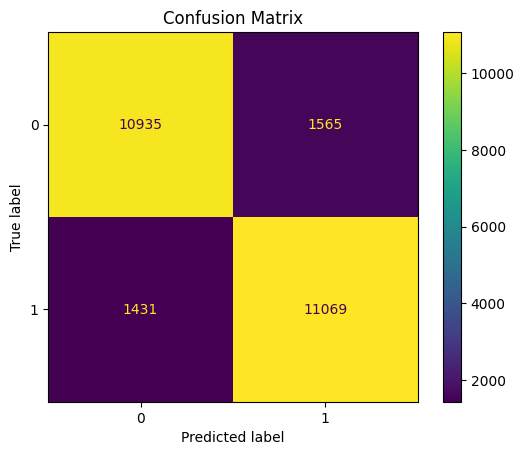

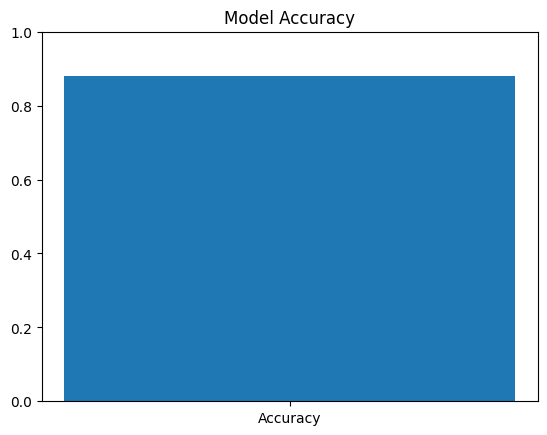

--------------------------------------------------
Review: this new phone is amazing
Negative probability: 0.07037401531445675
Positive probability: 0.9296259846855432
Prediction: Positive
--------------------------------------------------
Review: this movie is terrible and boring
Negative probability: 0.9947071850344776
Positive probability: 0.005292814965522362
Prediction: Negative
--------------------------------------------------
Review: the acting was bad and the story was boring
Negative probability: 0.9767385948171264
Positive probability: 0.023261405182873528
Prediction: Negative
--------------------------------------------------
Review: I loved the training coop
Negative probability: 0.08999924731034559
Positive probability: 0.9100007526896544
Prediction: Positive
--------------------------------------------------
Review: the game was too slow and disappointing
Negative probability: 0.9256616750394498
Positive probability: 0.07433832496055016
Prediction: Negative


In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(test_labels, predictions)
plt.title("Confusion Matrix")
plt.show()

plt.bar(["Accuracy"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()

def test_custom_reviews():
    reviews = [
        "this new phone is amazing",
        "this movie is terrible and boring",
        "the acting was bad and the story was boring",
        "I loved the training coop",
        "the game was too slow and disappointing"
    ]

    for review in reviews:
        print("-" * 50)
        predict_sentiment(review)

test_custom_reviews()